In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
np.random.seed(42)

In [ ]:
data = pd.read_csv('Advertising.csv')
print("Raw columns:", list(data.columns))

# Drop the unnamed index column that came from the CSV export
if data.columns[0].startswith('Unnamed') or data.columns[0] == '':
    data = data.drop(columns=[data.columns[0]])

print("Columns after cleanup:", list(data.columns))

Raw columns: ['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']
Columns after dropping index column: ['TV', 'radio', 'newspaper', 'sales']

In [ ]:
data.head()

      TV  radio  newspaper  sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

In [ ]:
print('Shape (rows, columns):', data.shape)

Shape (rows, columns): (200, 4)

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

In [ ]:
print("Missing values per column:")
print(data.isnull().sum())
print("\nNumber of duplicate rows:", data.duplicated().sum())

Missing values per column:
 TV           0
radio        0
newspaper    0
sales        0
dtype: int64

Number of duplicate rows: 0

In [ ]:
data.describe()

               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000

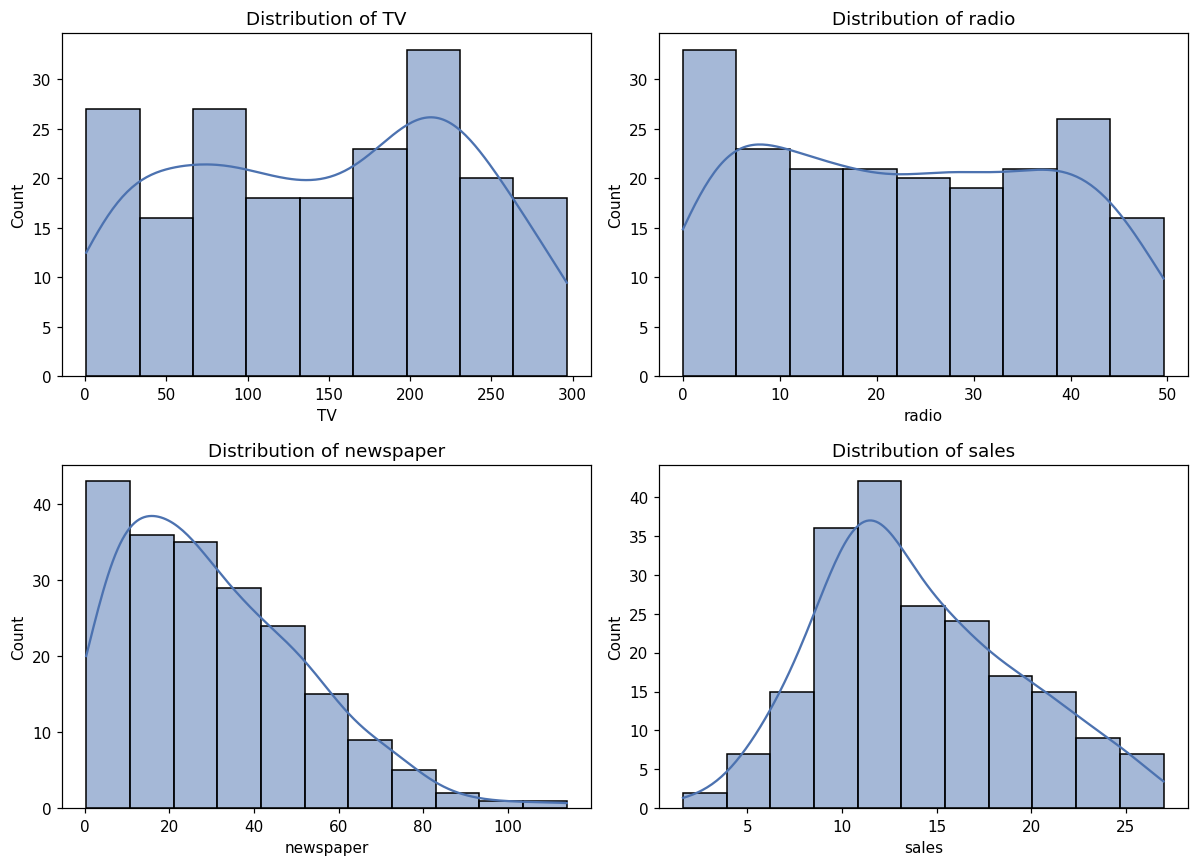

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), ['TV', 'radio', 'newspaper', 'sales']):
    sns.histplot(data[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

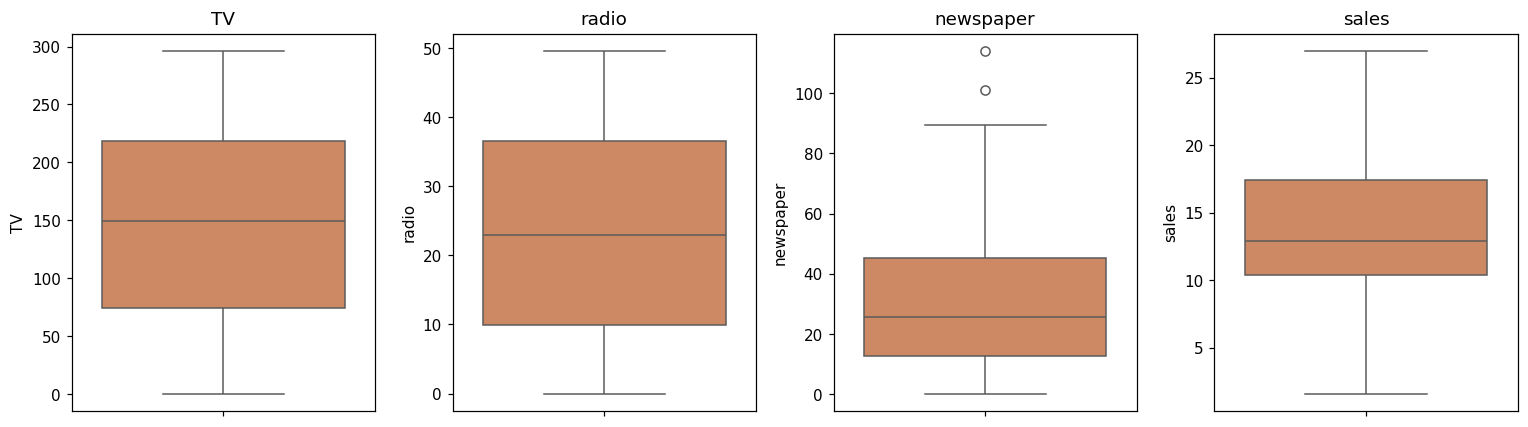

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, ['TV', 'radio', 'newspaper', 'sales']):
    sns.boxplot(y=data[col], ax=ax, color='#DD8452')
    ax.set_title(col)
plt.tight_layout()
plt.show()

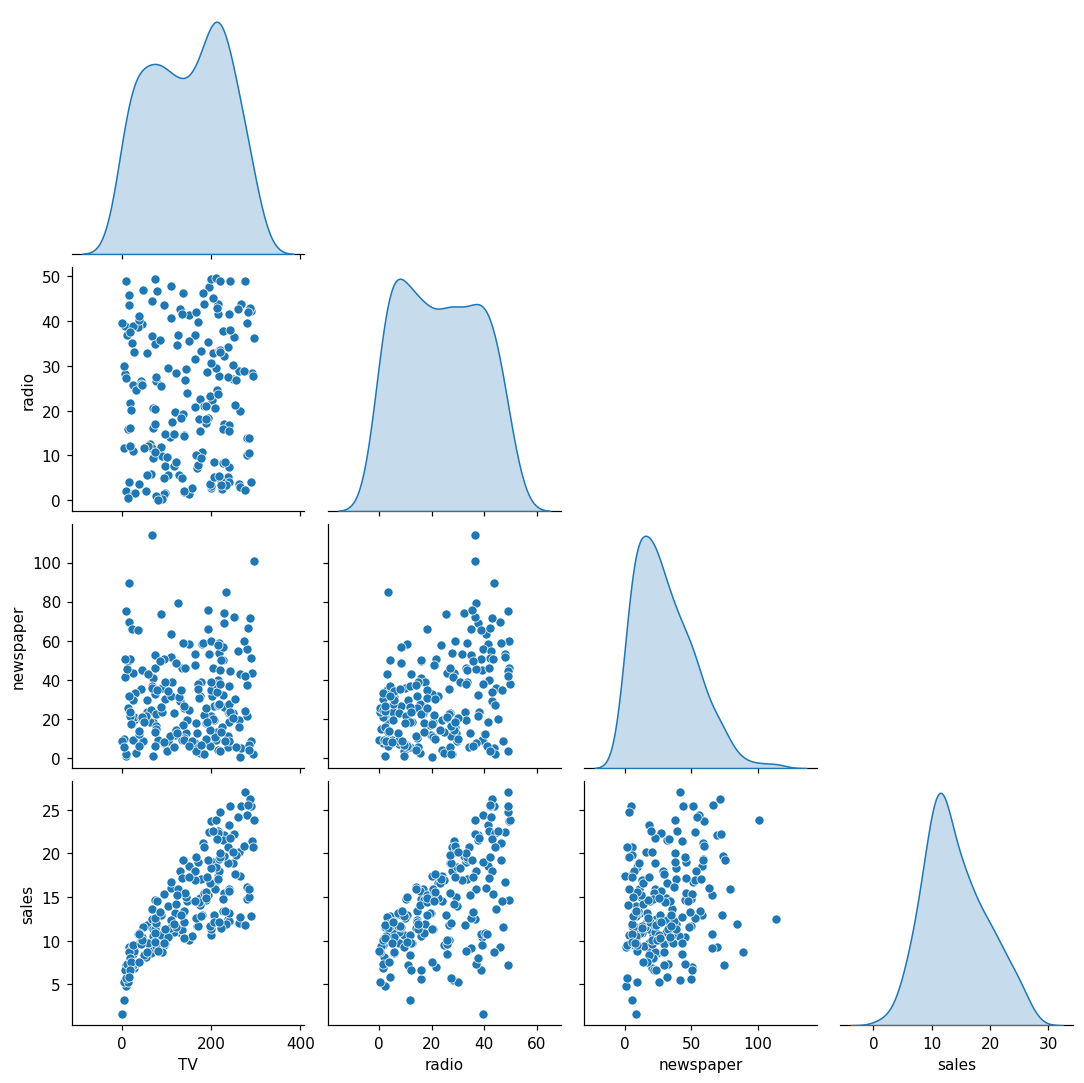

In [ ]:
sns.pairplot(data, diag_kind='kde', corner=True)
plt.show()

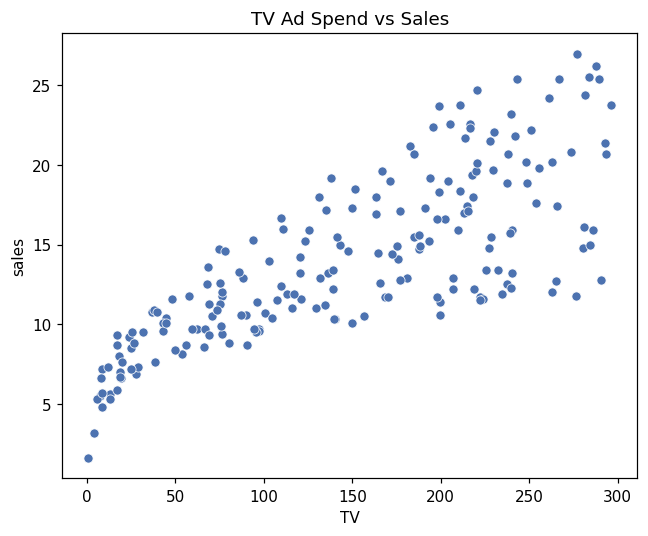

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=data, x='TV', y='sales', color='#4C72B0')
plt.title('TV Ad Spend vs Sales')
plt.show()

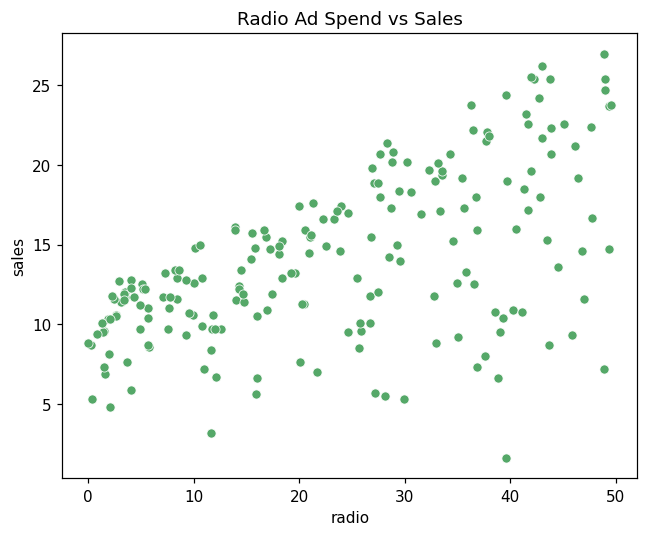

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=data, x='radio', y='sales', color='#55A868')
plt.title('Radio Ad Spend vs Sales')
plt.show()

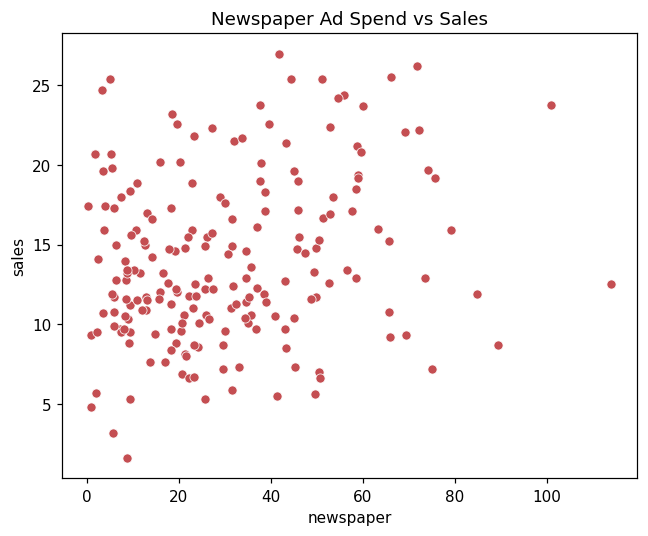

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=data, x='newspaper', y='sales', color='#C44E52')
plt.title('Newspaper Ad Spend vs Sales')
plt.show()

In [ ]:
data_correlation = data.corr()
data_correlation

                 TV     radio  newspaper     sales
TV         1.000000  0.054809   0.056648  0.782224
radio      0.054809  1.000000   0.354104  0.576223
newspaper  0.056648  0.354104   1.000000  0.228299
sales      0.782224  0.576223   0.228299  1.000000

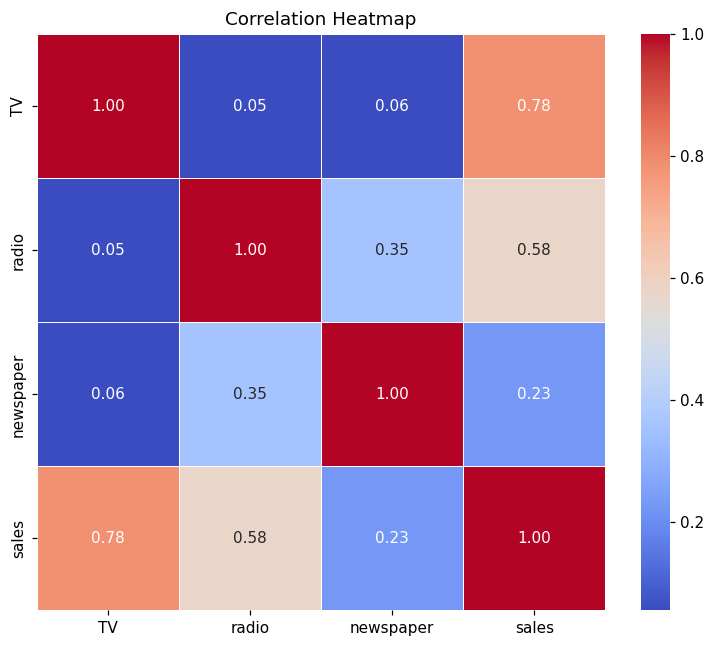

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(data_correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X = data.drop('sales', axis=1)   # features: TV, radio, newspaper
y = data['sales']                 # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)                     # fit ONLY on training data

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)  # test set only ever transformed, never fit

print("Scaler fitted on X_train only (mean/std from training data).")
print("Train mean after scaling (~0):", np.round(X_train_scaled.mean(axis=0), 3))
print("Train std after scaling (~1):", np.round(X_train_scaled.std(axis=0), 3))

Scaler fitted on X_train only (mean/std from training data).
Train mean after scaling (~0): [-0. -0.  0.]
Train std after scaling (~1): [1. 1. 1.]

In [ ]:
def Linear_Regression(x_train, y_train):
    model = LinearRegression()
    model.fit(x_train, y_train)
    return model

def Lasso_Regression(x_train, y_train):
    model = Lasso(alpha=0.8, max_iter=10000)
    model.fit(x_train, y_train)
    return model

def Ridge_Regression(x_train, y_train):
    model = Ridge(alpha=0.9)
    model.fit(x_train, y_train)
    return model

def RandomForest_Regression(x_train, y_train):
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(x_train, y_train)
    return model

print("Model builder functions defined: Linear, Lasso, Ridge, RandomForest")

Model builder functions defined: Linear, Lasso, Ridge, RandomForest

In [ ]:
def build_train_evaluate(reg_fn, name, x_train, y_train, x_test, y_test):
    model = reg_fn(x_train, y_train)
    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    print(f"--- {name} ---")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test  R2: {test_r2:.4f}")
    print(f"Test  MAE: {mae:.4f}")
    print(f"Test  RMSE: {rmse:.4f}\n")

    return {
        'model': model, 'name': name,
        'train_r2': train_r2, 'test_r2': test_r2,
        'mae': mae, 'rmse': rmse,
        'test_pred': test_pred
    }

print("Evaluation function defined (computes Train R2, Test R2, MAE, RMSE).")

Evaluation function defined (computes Train R2, Test R2, MAE, RMSE).

In [ ]:
results = {}
results['Linear Regression'] = build_train_evaluate(
    Linear_Regression, "Linear Regression", X_train_scaled, y_train, X_test_scaled, y_test
)

--- Linear Regression ---
Train R2: 0.8957
Test  R2: 0.8994
Test  MAE: 1.4608
Test  RMSE: 1.7816

In [ ]:
results['Lasso Regression'] = build_train_evaluate(
    Lasso_Regression, "Lasso Regression", X_train_scaled, y_train, X_test_scaled, y_test
)

--- Lasso Regression ---
Train R2: 0.8488
Test  R2: 0.8452
Test  MAE: 1.7096
Test  RMSE: 2.2104

In [ ]:
results['Ridge Regression'] = build_train_evaluate(
    Ridge_Regression, "Ridge Regression", X_train_scaled, y_train, X_test_scaled, y_test
)

--- Ridge Regression ---
Train R2: 0.8957
Test  R2: 0.8989
Test  MAE: 1.4640
Test  RMSE: 1.7866

In [ ]:
results['Random Forest'] = build_train_evaluate(
    RandomForest_Regression, "Random Forest", X_train_scaled, y_train, X_test_scaled, y_test
)

--- Random Forest ---
Train R2: 0.9967
Test  R2: 0.9818
Test  MAE: 0.6296
Test  RMSE: 0.7575

In [ ]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train R2': [results[k]['train_r2'] for k in results],
    'Test R2': [results[k]['test_r2'] for k in results],
    'Test MAE': [results[k]['mae'] for k in results],
    'Test RMSE': [results[k]['rmse'] for k in results],
}).sort_values('Test R2', ascending=False).reset_index(drop=True)

comparison_df

               Model  Train R2   Test R2  Test MAE  Test RMSE
0      Random Forest  0.996693  0.981820  0.629625   0.757523
1  Linear Regression  0.895701  0.899438  1.460757   1.781600
2   Ridge Regression  0.895674  0.898868  1.463950   1.786639
3   Lasso Regression  0.848769  0.845201  1.709595   2.210432

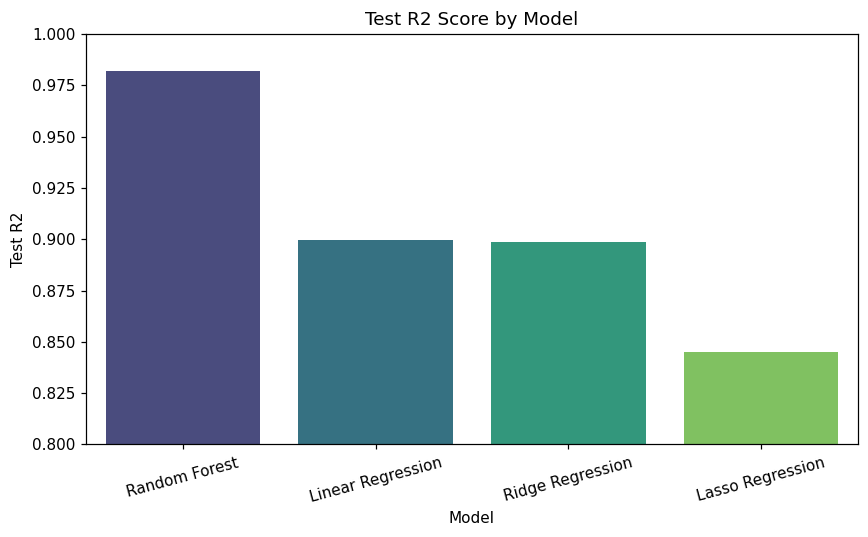

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_df, x='Model', y='Test R2', hue='Model', legend=False, palette='viridis')
plt.title('Test R2 Score by Model')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.show()

Best performing model: Random Forest (Test R2 = 0.9818)

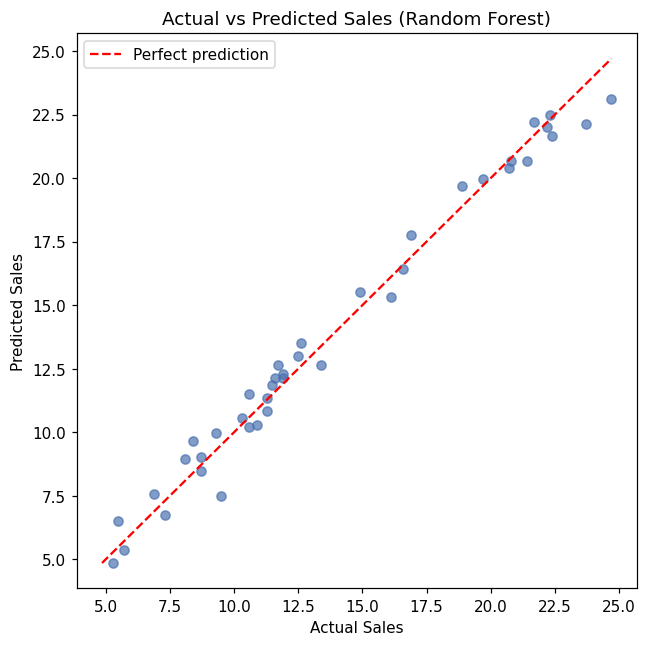

In [ ]:
best_name = comparison_df.iloc[0]['Model']
best = results[best_name]
print(f"Best performing model: {best_name} (Test R2 = {best['test_r2']:.4f})")

plt.figure(figsize=(6,6))
plt.scatter(y_test, best['test_pred'], alpha=0.7, color='#4C72B0')
lims = [min(y_test.min(), best['test_pred'].min()), max(y_test.max(), best['test_pred'].max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Actual vs Predicted Sales ({best_name})')
plt.legend()
plt.show()

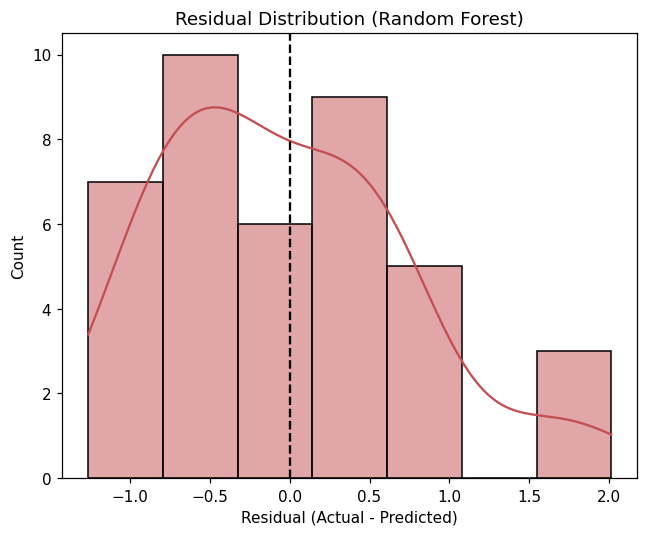

In [ ]:
residuals = y_test.values - best['test_pred']

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True, color='#C44E52')
plt.axvline(0, color='black', linestyle='--')
plt.title(f'Residual Distribution ({best_name})')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

In [ ]:
lin_model = results['Linear Regression']['model']
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lin_model.coef_
}).sort_values('Coefficient', ascending=False)

coef_df

     Feature  Coefficient
0         TV     3.764196
1      radio     2.792307
2  newspaper     0.055976
/home/claude/run_analysis.py:246: FutureWarning: 

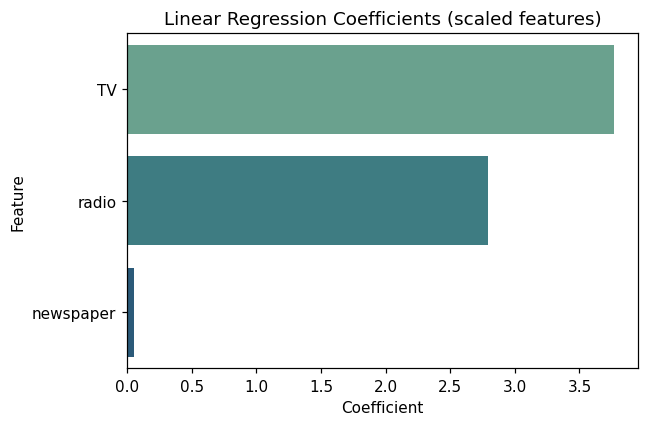

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', legend=False, palette='crest')
plt.title('Linear Regression Coefficients (scaled features)')
plt.show()